# Getting Started with Complexplorer

Welcome to Complexplorer! This notebook will guide you through your first steps in visualizing complex functions.

## What You'll Learn

1. Basic setup and imports
2. Creating your first visualization
3. Understanding domains (Rectangle, Disk, Annulus)
4. Using colormaps for enhanced visualizations
5. Introduction to high-quality 3D plots with PyVista

Let's begin!

## Installation

If you haven't installed complexplorer yet:

```bash
# Basic installation
pip install complexplorer

# With PyVista for high-quality 3D (recommended)
pip install "complexplorer[pyvista]"

# Or install everything
pip install "complexplorer[all]"
```

## Basic Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp
import pyvista as pv

# In notebooks, render PyVista 3D inline as static images (reproducible, no external window).
# For interactive/high-quality 3D, run the terminal scripts in examples/scripts/ instead.
pv.set_jupyter_backend('static')

## Your First Visualization

Let's start with a simple polynomial function: $f(z) = z^2$

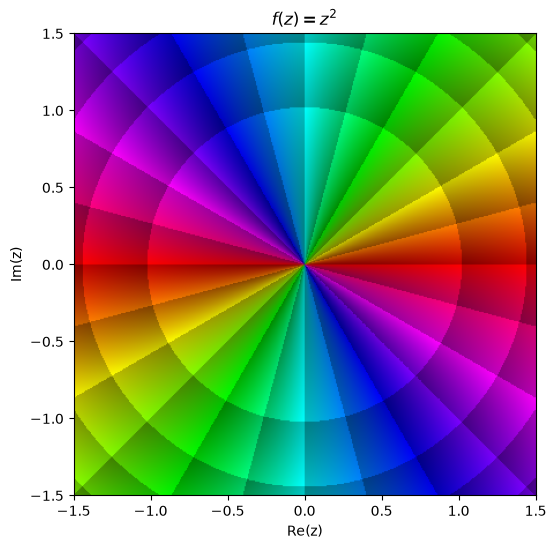

In [2]:
# Define a complex function
def f(z):
    return z**2

# Create a domain (region of complex plane to visualize)
domain = cp.Rectangle(3, 3)  # 3x3 rectangle centered at origin

# Create visualization
fig, ax = plt.subplots(figsize=(6, 6))
cp.plot(domain, f, ax=ax)
ax.set_title(r"$f(z) = z^2$")
plt.show()

### Understanding the Visualization

- **Colors represent phase**: The hue shows the argument (angle) of the complex number
- **Red = positive real** (phase = 0)
- **Cyan = negative real** (phase = π)
- **Green/Yellow = positive imaginary**
- **Blue/Magenta = negative imaginary**

Notice how $f(z) = z^2$ doubles the phase angle!

## Side-by-Side Visualization

Often it's helpful to see the domain and codomain side by side:

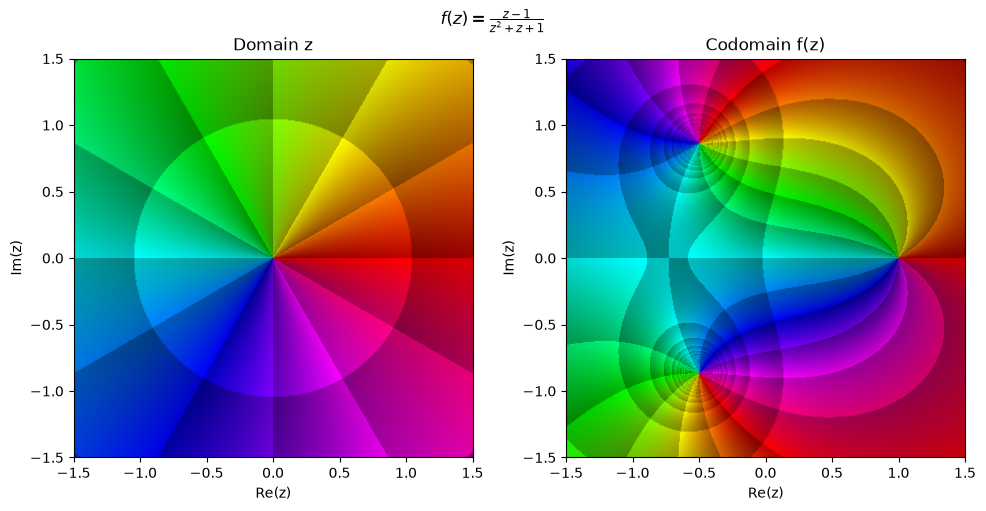

In [3]:
# A more interesting function
def f(z):
    return (z - 1) / (z**2 + z + 1)

# Side-by-side plot
fig = cp.pair_plot(domain, f, title=r"$f(z) = \frac{z - 1}{z^2 + z + 1}$")
plt.show()

## Working with Different Domains

Complexplorer supports various domain shapes:

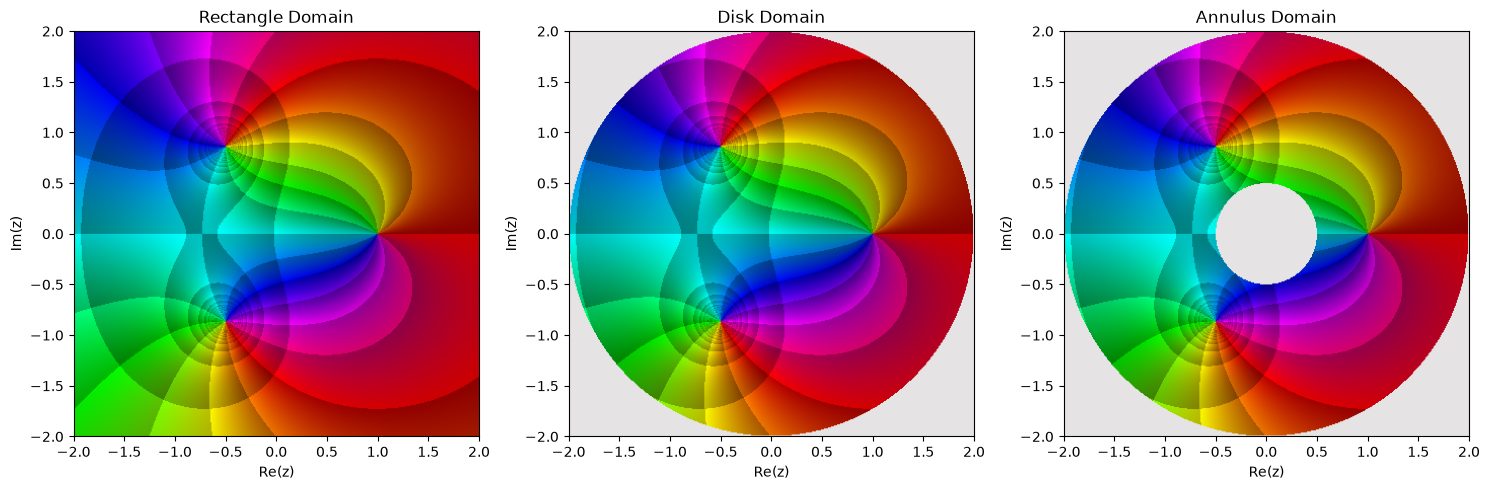

In [4]:
# Rectangle domain
rect = cp.Rectangle(re_length=4, im_length=3, center=0+0j, )

# Disk domain
disk = cp.Disk(radius=2, center=0+0j)

# Annulus (ring) domain
annulus = cp.Annulus(inner_radius=0.5, outer_radius=2, center=0+0j)

# Visualize the same function on different domains
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cp.plot(rect, f, ax=axes[0])
axes[0].set_title("Rectangle Domain")

cp.plot(disk, f, ax=axes[1])
axes[1].set_title("Disk Domain")

cp.plot(annulus, f, ax=axes[2])
axes[2].set_title("Annulus Domain")

plt.tight_layout()
plt.show()

## Enhanced Phase Portraits

Basic phase portraits show only the argument. Enhanced phase portraits also encode the modulus (magnitude):

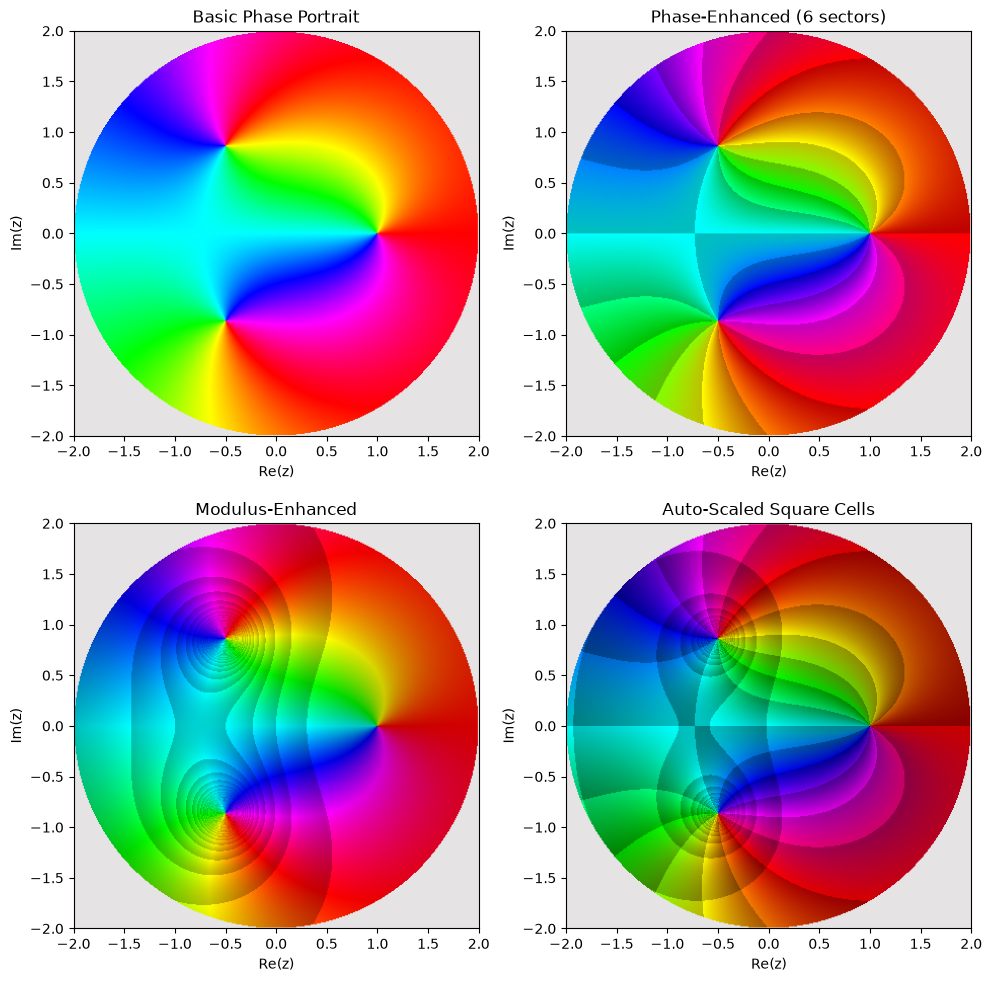

In [5]:
# Basic phase portrait
basic_cmap = cp.Phase()

# Enhanced with phase sectors
phase_enhanced = cp.Phase(n_phi=6)  # 6 phase sectors

# Enhanced with modulus contours
modulus_enhanced = cp.Phase(r_linear_step=0.5)  # Contours every 0.5 units

# Both enhancements with auto-scaling
auto_scaled = cp.Phase(n_phi=6, auto_scale_r=True)  # Automatically creates square cells

# Compare them
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

cp.plot(disk, f, cmap=basic_cmap, ax=axes[0,0])
axes[0,0].set_title("Basic Phase Portrait")

cp.plot(disk, f, cmap=phase_enhanced, ax=axes[0,1])
axes[0,1].set_title("Phase-Enhanced (6 sectors)")

cp.plot(disk, f, cmap=modulus_enhanced, ax=axes[1,0])
axes[1,0].set_title("Modulus-Enhanced")

cp.plot(disk, f, cmap=auto_scaled, ax=axes[1,1])
axes[1,1].set_title("Auto-Scaled Square Cells")

plt.tight_layout()
plt.show()

## Introduction to 3D Visualization

3D landscapes use **PyVista** — the sole 3D backend as of 3.0 (the old matplotlib 3D
functions were removed). In notebooks the *static* backend (set above) embeds each plot as
an image. For interactive rotation/zoom and the best anti-aliasing, run the scripts in
`examples/scripts/` from a terminal.

C:\Repos\complexplorer\complexplorer\plotting\pyvista\plot_3d.py:221: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


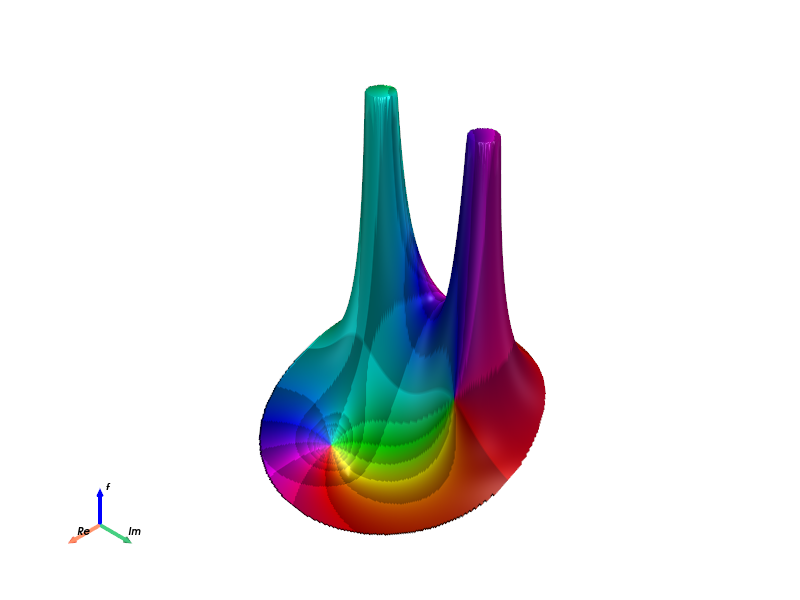

In [6]:
# 3D analytic landscape (PyVista). z_max limits the vertical range for a cleaner view.
cp.plot_landscape_pv(domain=disk, func=f, cmap=auto_scaled, z_max=5, resolution=200)

### Rendering note

Because the static backend is set, the plot above is embedded as an image. There is no
longer an inline-vs-external quality tradeoff to manage in the notebook — for full
interactivity, use the terminal scripts in `examples/scripts/`.

## Exercises

Now it's your turn! Try these exercises:

### Exercise 1: Explore Different Functions
Try visualizing these functions:
- $f(z) = z^3 - 1$ (cube roots of unity)
- $f(z) = \sin(z)$ (sine function)
- $f(z) = e^z$ (exponential)
- $f(z) = \frac{1}{z}$ (hint: use an Annulus domain to avoid the pole at 0)

<Axes: xlabel='Re(z)', ylabel='Im(z)'>

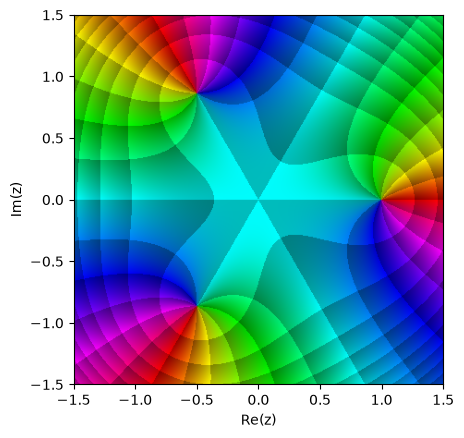

In [7]:
# Your code here
def my_func(z):
    return z**3 - 1  # Try different functions!

# Visualize it
cp.plot(domain, my_func)

### Exercise 2: Create Custom Domains
Try creating domains with different parameters:
- A tall rectangle (re_length=2, im_length=6)
- A disk centered at 1+i with radius 1.5
- A thin annulus (inner_radius=1.8, outer_radius=2.0)

In [8]:
# Your domain experiments here
# my_domain = cp.Rectangle(re_length=4, im_length=2)
# cp.plot(my_domain, f)

### Exercise 3: Experiment with Colormaps
Try different colormap parameters:
- Phase with different n_phi values (try 3, 8, 12)
- Different r_linear_step values
- Compare auto_scale_r=True with manual settings

In [9]:
# Your colormap experiments here
# my_cmap = Phase(...)
# plot(domain, f, cmap=my_cmap)

## Summary

You've learned:
1. ✓ How to create basic visualizations with `plot()`
2. ✓ Using different domains (Rectangle, Disk, Annulus)
3. ✓ Enhanced phase portraits with automatic scaling
4. ✓ High-quality 3D with PyVista (static backend inline; terminal scripts for interactivity)
5. ✓ Performance benefits of PyVista

## Next Steps

- Check out `advanced_features.ipynb` for:
  - More colormap types (Chessboard, PolarChessboard, LogRings)
  - Riemann sphere visualizations
  - STL export for 3D printing
  - Domain composition
  
- See `api_cookbook.ipynb` for:
  - Common function patterns
  - Best practices
  - Performance optimization

Happy exploring! 🌈